# 🔭 Kepler Telescope Data Analysis

## Comprehensive Analysis of Kepler Exoplanet Cumulative Dataset

**Author:** Stellar Analytics Team  
**Date:** 2026-02-14

This notebook performs:
1. Data Loading & Initial Exploration
2. Data Cleaning & Preprocessing
3. Exploratory Data Analysis (EDA)
4. Classification Model Development (8 Models)
5. Regression Model Development (8 Models)
6. Key Insights & Findings

### Classification Models
Logistic Regression, Random Forest, Gradient Boosting, KNN, Neural Network (MLP), SVM, LightGBM, Voting Ensemble

### Regression Models
Linear, Ridge, Lasso, KNN, Random Forest, Gradient Boosting, LightGBM, Neural Network (MLP)


## Setup & Imports

In [2]:
%matplotlib inline


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               VotingClassifier, RandomForestRegressor,
                               GradientBoostingRegressor)
from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.svm import SVC
from sklearn.metrics import (classification_report, confusion_matrix, 
                             accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, roc_curve,
                             mean_absolute_error, mean_squared_error, r2_score)
from lightgbm import LGBMClassifier, LGBMRegressor
from scipy import stats
import os

# Set random seed for reproducibility
np.random.seed(42)
warnings.filterwarnings('ignore')

# Configure matplotlib for better plots
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Create output directory for visualizations
if not os.path.exists('visualizations'):
    os.makedirs('visualizations')

print("="*80)
print("KEPLER TELESCOPE DATA ANALYSIS")
print("="*80)
print()


KEPLER TELESCOPE DATA ANALYSIS



## Section 1: Data Loading & Initial Exploration

In [3]:
print("\n" + "="*80)
print("SECTION 1: DATA LOADING & INITIAL EXPLORATION")
print("="*80 + "\n")

# Load the dataset
print("Loading Kepler cumulative dataset...")
df = pd.read_csv('cumulative.csv')
print("✓ Dataset loaded successfully!\n")

# Display basic information
print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns\n")

print("Column Names:")
print("-" * 40)
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

print(f"\n\nData Types Summary:")
print("-" * 40)
print(df.dtypes.value_counts())

print(f"\n\nFirst 5 Rows:")
print("-" * 80)
print(df.head())

print(f"\n\nBasic Statistical Summary:")
print("-" * 80)
print(df.describe())

print(f"\n\nMissing Values Summary:")
print("-" * 40)
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing_Count': missing,
    'Percentage': missing_pct
}).sort_values('Percentage', ascending=False)
print(missing_df[missing_df['Missing_Count'] > 0].head(20))



SECTION 1: DATA LOADING & INITIAL EXPLORATION

Loading Kepler cumulative dataset...
✓ Dataset loaded successfully!

Dataset Shape: 9,564 rows × 50 columns

Column Names:
----------------------------------------
 1. rowid
 2. kepid
 3. kepoi_name
 4. kepler_name
 5. koi_disposition
 6. koi_pdisposition
 7. koi_score
 8. koi_fpflag_nt
 9. koi_fpflag_ss
10. koi_fpflag_co
11. koi_fpflag_ec
12. koi_period
13. koi_period_err1
14. koi_period_err2
15. koi_time0bk
16. koi_time0bk_err1
17. koi_time0bk_err2
18. koi_impact
19. koi_impact_err1
20. koi_impact_err2
21. koi_duration
22. koi_duration_err1
23. koi_duration_err2
24. koi_depth
25. koi_depth_err1
26. koi_depth_err2
27. koi_prad
28. koi_prad_err1
29. koi_prad_err2
30. koi_teq
31. koi_teq_err1
32. koi_teq_err2
33. koi_insol
34. koi_insol_err1
35. koi_insol_err2
36. koi_model_snr
37. koi_tce_plnt_num
38. koi_tce_delivname
39. koi_steff
40. koi_steff_err1
41. koi_steff_err2
42. koi_slogg
43. koi_slogg_err1
44. koi_slogg_err2
45. koi_srad
46. 

## Section 2: Data Cleaning & Preprocessing

In [4]:
# Create a copy for processing
df_clean = df.copy()

print("Step 1: Identifying and handling duplicates...")
initial_rows = len(df_clean)
df_clean = df_clean.drop_duplicates()
duplicates_removed = initial_rows - len(df_clean)
print(f"✓ Removed {duplicates_removed} duplicate rows")

# Focus on key columns for exoplanet detection
print("\nStep 2: Selecting relevant features...")

# Key columns based on Kepler data documentation
key_columns = [
    'koi_disposition',  # Target variable: CONFIRMED, FALSE POSITIVE, CANDIDATE
    'koi_score',        # Disposition score
    'koi_period',       # Orbital period
    'koi_teq',          # Equilibrium temperature
    'koi_insol',        # Insolation flux
    'koi_depth',        # Transit depth
    'koi_duration',     # Transit duration
    'koi_prad',         # Planetary radius
    'koi_srad',         # Stellar radius
    'koi_smass',        # Stellar mass
    'koi_steff',        # Stellar effective temperature
    'ra',               # Right ascension
    'dec'               # Declination
]

# Filter columns that exist in the dataset
available_columns = [col for col in key_columns if col in df_clean.columns]
df_clean = df_clean[available_columns]
print(f"✓ Selected {len(available_columns)} key features")

print("\nStep 3: Handling missing values...")
print("Missing values before cleaning:")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

# Separate features and target
if 'koi_disposition' in df_clean.columns:
    target_col = 'koi_disposition'
    # Remove rows with missing target
    df_clean = df_clean.dropna(subset=[target_col])
    print(f"✓ Removed rows with missing target variable")
    
    # For numerical features, use median imputation
    numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
    
    for col in numerical_cols:
        if df_clean[col].isnull().sum() > 0:
            median_val = df_clean[col].median()
            df_clean[col].fillna(median_val, inplace=True)
    
    print(f"✓ Imputed missing values in numerical features using median")

print("\nStep 4: Outlier detection and handling...")
# Use IQR method for outlier detection
numerical_features = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numerical_features = [col for col in numerical_features if col not in ['ra', 'dec']]  # Keep coordinates

outliers_count = 0
for col in numerical_features:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # Using 3*IQR for conservative outlier removal
    upper_bound = Q3 + 3 * IQR
    
    outliers_in_col = ((df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)).sum()
    outliers_count += outliers_in_col
    
    # Cap outliers instead of removing them to preserve data
    df_clean[col] = df_clean[col].clip(lower=lower_bound, upper=upper_bound)

print(f"✓ Handled {outliers_count} outliers using capping method")

print("\nStep 5: Feature Engineering...")
# Create new features
if 'koi_prad' in df_clean.columns and 'koi_srad' in df_clean.columns:
    df_clean['planet_star_radius_ratio'] = df_clean['koi_prad'] / df_clean['koi_srad']
    print("✓ Created: planet_star_radius_ratio")

if 'koi_period' in df_clean.columns and 'koi_teq' in df_clean.columns:
    df_clean['period_temp_product'] = df_clean['koi_period'] * df_clean['koi_teq']
    print("✓ Created: period_temp_product")

print(f"\n✓ Data cleaning complete!")
print(f"Final dataset shape: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")


Step 1: Identifying and handling duplicates...
✓ Removed 0 duplicate rows

Step 2: Selecting relevant features...
✓ Selected 12 key features

Step 3: Handling missing values...
Missing values before cleaning:
koi_score    1510
koi_teq       363
koi_insol     321
koi_depth     363
koi_prad      363
koi_srad      363
koi_steff     363
dtype: int64
✓ Removed rows with missing target variable
✓ Imputed missing values in numerical features using median

Step 4: Outlier detection and handling...
✓ Handled 6336 outliers using capping method

Step 5: Feature Engineering...
✓ Created: planet_star_radius_ratio
✓ Created: period_temp_product

✓ Data cleaning complete!
Final dataset shape: 9,564 rows × 14 columns


## Section 3: Exploratory Data Analysis (EDA)

In [5]:
print("Generating comprehensive visualizations...\n")


Generating comprehensive visualizations...



### Figure 1: Target Variable Distribution

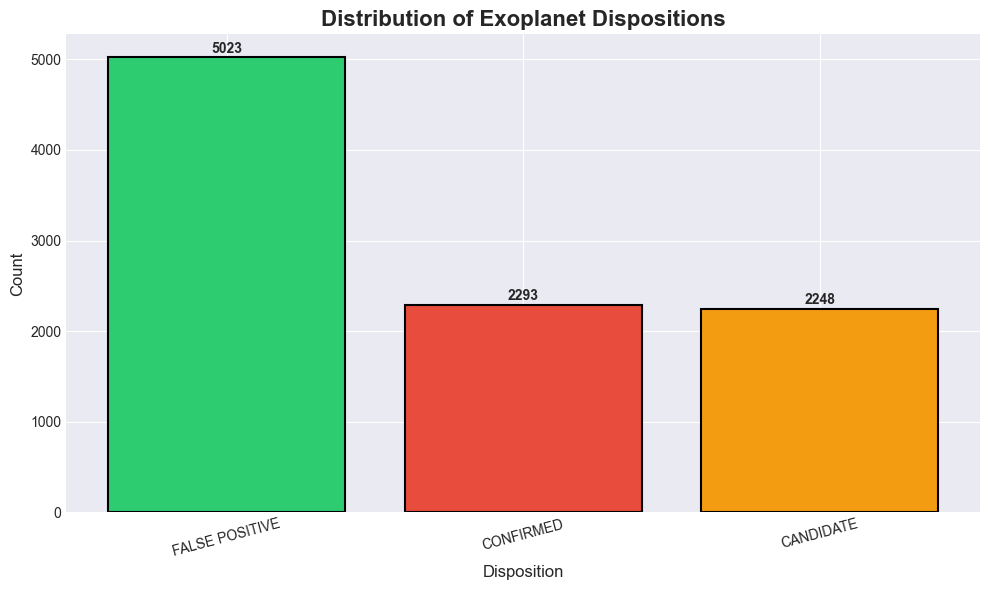

✓ Saved: 01_disposition_distribution.png

Disposition Breakdown:
  FALSE POSITIVE: 5,023 (52.52%)
  CONFIRMED: 2,293 (23.98%)
  CANDIDATE: 2,248 (23.50%)


In [6]:
plt.figure(figsize=(10, 6))
if 'koi_disposition' in df_clean.columns:
    disposition_counts = df_clean['koi_disposition'].value_counts()
    colors = ['#2ecc71', '#e74c3c', '#f39c12']
    plt.bar(disposition_counts.index, disposition_counts.values, color=colors, edgecolor='black', linewidth=1.5)
    plt.title('Distribution of Exoplanet Dispositions', fontsize=16, fontweight='bold')
    plt.xlabel('Disposition', fontsize=12)
    plt.ylabel('Count', fontsize=12)
    plt.xticks(rotation=15)
    for i, v in enumerate(disposition_counts.values):
        plt.text(i, v + 50, str(v), ha='center', fontweight='bold')
    plt.tight_layout()
    plt.savefig('visualizations/01_disposition_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 01_disposition_distribution.png")
    
    print(f"\nDisposition Breakdown:")
    for disp, count in disposition_counts.items():
        pct = (count / len(df_clean)) * 100
        print(f"  {disp}: {count:,} ({pct:.2f}%)")


### Figure 2: Correlation Heatmap

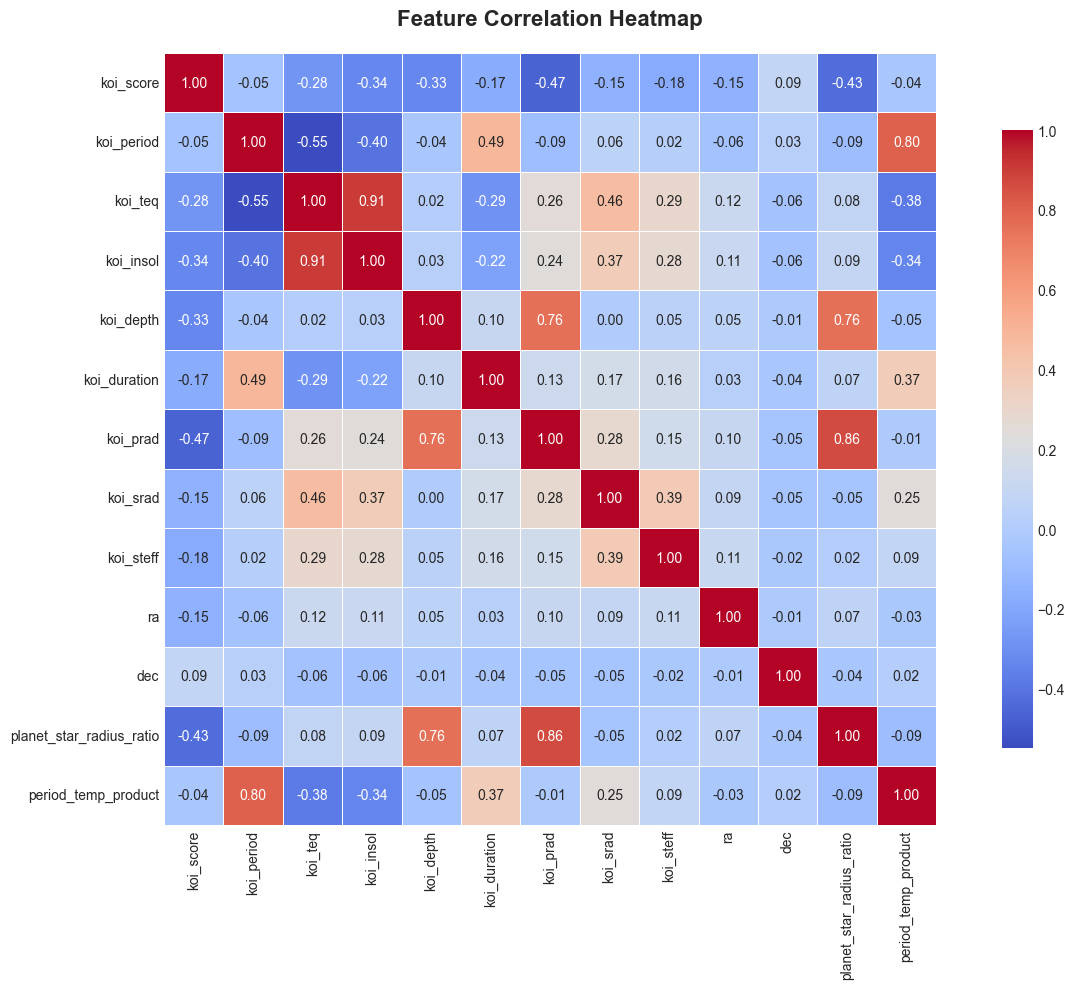

✓ Saved: 02_correlation_heatmap.png


In [7]:
numerical_for_corr = df_clean.select_dtypes(include=[np.number]).columns.tolist()
if len(numerical_for_corr) > 2:
    plt.figure(figsize=(14, 10))
    correlation_matrix = df_clean[numerical_for_corr].corr()
    sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('visualizations/02_correlation_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 02_correlation_heatmap.png")


### Figure 3: Distribution of Orbital Period

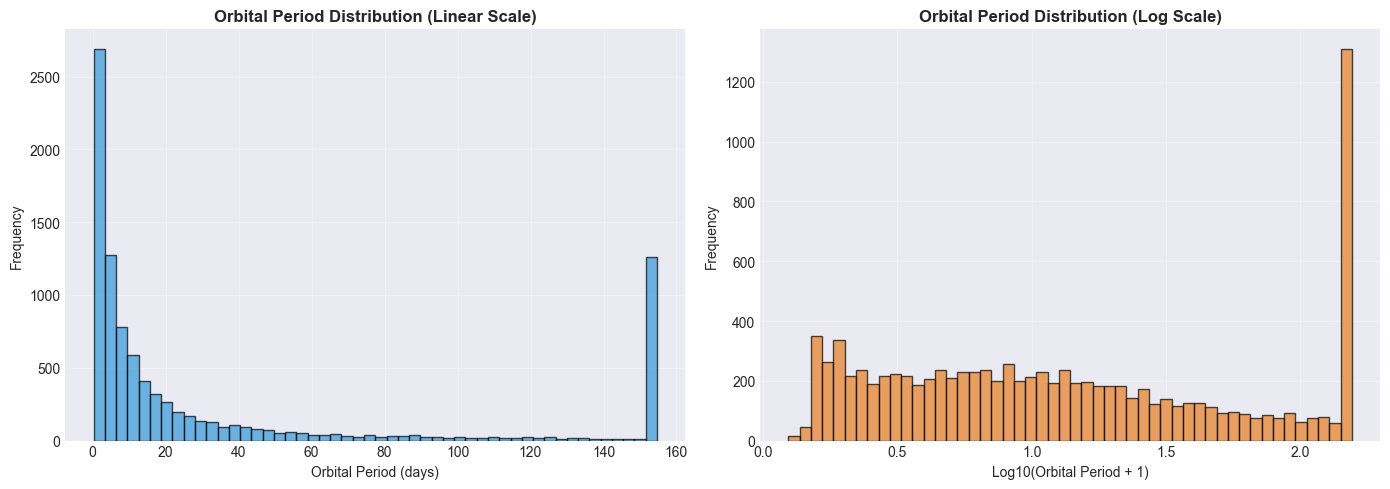

✓ Saved: 03_orbital_period_distribution.png


In [8]:
if 'koi_period' in df_clean.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Linear scale
    axes[0].hist(df_clean['koi_period'].dropna(), bins=50, color='#3498db', edgecolor='black', alpha=0.7)
    axes[0].set_title('Orbital Period Distribution (Linear Scale)', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Orbital Period (days)', fontsize=10)
    axes[0].set_ylabel('Frequency', fontsize=10)
    axes[0].grid(alpha=0.3)
    
    # Log scale
    axes[1].hist(np.log10(df_clean['koi_period'].dropna() + 1), bins=50, color='#e67e22', edgecolor='black', alpha=0.7)
    axes[1].set_title('Orbital Period Distribution (Log Scale)', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Log10(Orbital Period + 1)', fontsize=10)
    axes[1].set_ylabel('Frequency', fontsize=10)
    axes[1].grid(alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('visualizations/03_orbital_period_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 03_orbital_period_distribution.png")


### Figure 4: Planetary Radius Distribution

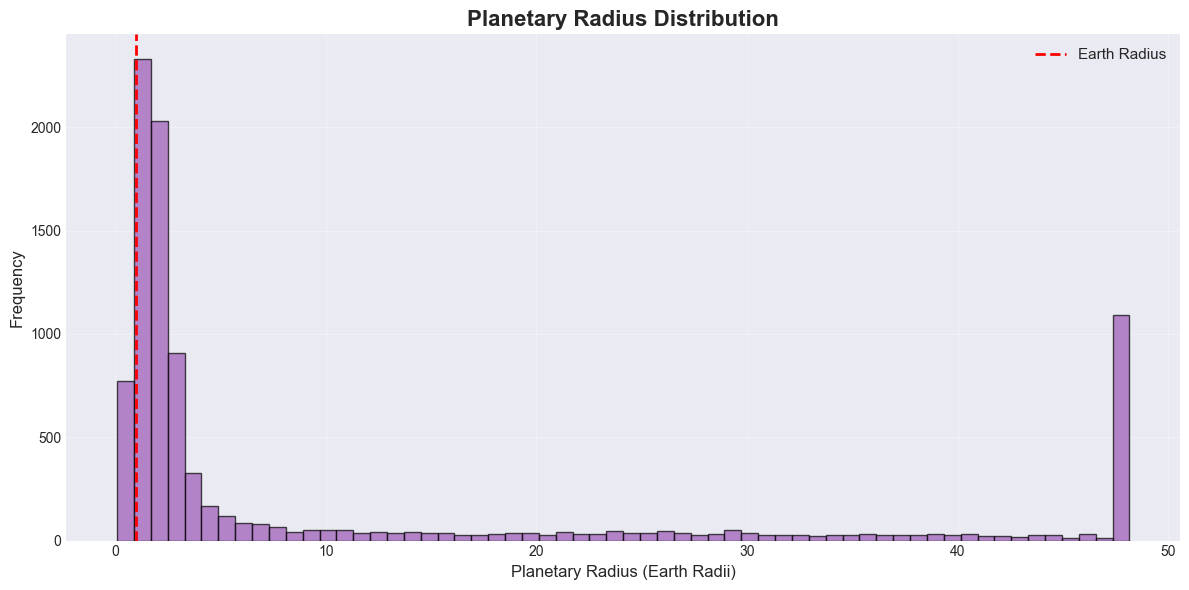

✓ Saved: 04_planetary_radius_distribution.png


In [9]:
if 'koi_prad' in df_clean.columns:
    plt.figure(figsize=(12, 6))
    plt.hist(df_clean['koi_prad'].dropna(), bins=60, color='#9b59b6', edgecolor='black', alpha=0.7)
    plt.axvline(1.0, color='red', linestyle='--', linewidth=2, label='Earth Radius')
    plt.title('Planetary Radius Distribution', fontsize=16, fontweight='bold')
    plt.xlabel('Planetary Radius (Earth Radii)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend(fontsize=11)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('visualizations/04_planetary_radius_distribution.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 04_planetary_radius_distribution.png")


### Figure 5: Stellar Temperature vs Planetary Radius

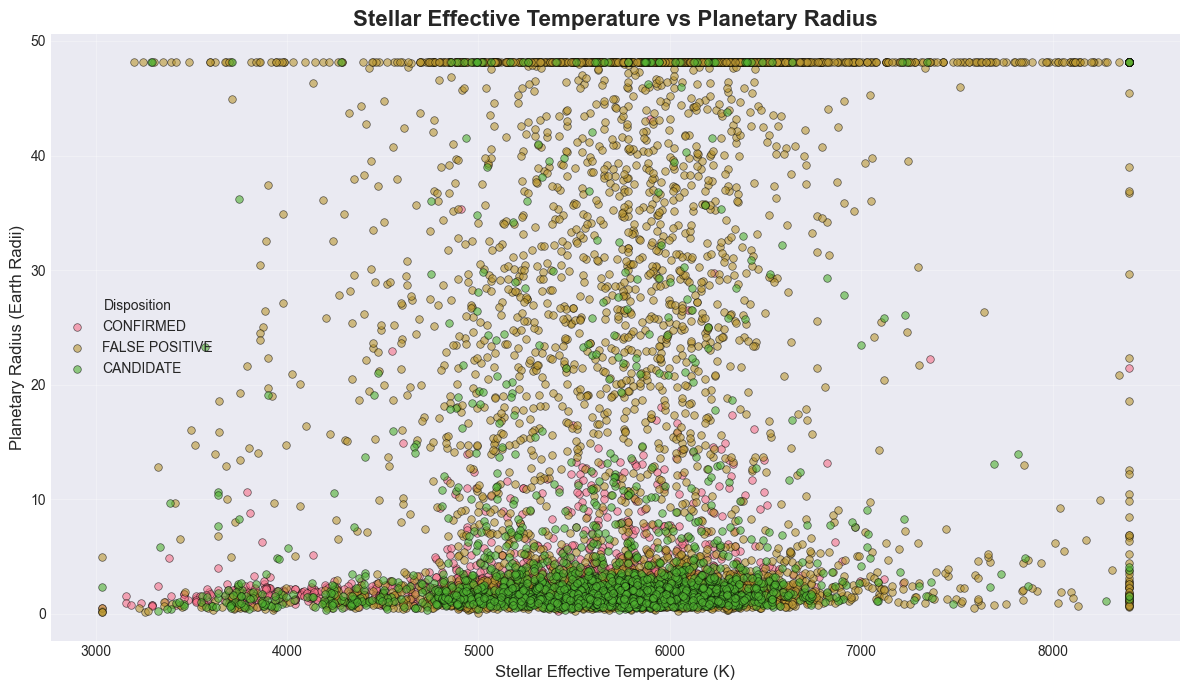

✓ Saved: 05_steff_vs_prad_scatter.png


In [10]:
if 'koi_steff' in df_clean.columns and 'koi_prad' in df_clean.columns and 'koi_disposition' in df_clean.columns:
    plt.figure(figsize=(12, 7))
    for disposition in df_clean['koi_disposition'].unique():
        subset = df_clean[df_clean['koi_disposition'] == disposition]
        plt.scatter(subset['koi_steff'], subset['koi_prad'], 
                   alpha=0.6, s=30, label=disposition, edgecolors='black', linewidth=0.5)
    plt.title('Stellar Effective Temperature vs Planetary Radius', fontsize=16, fontweight='bold')
    plt.xlabel('Stellar Effective Temperature (K)', fontsize=12)
    plt.ylabel('Planetary Radius (Earth Radii)', fontsize=12)
    plt.legend(title='Disposition', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('visualizations/05_steff_vs_prad_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 05_steff_vs_prad_scatter.png")


### Figure 6: Equilibrium Temperature Distribution by Disposition

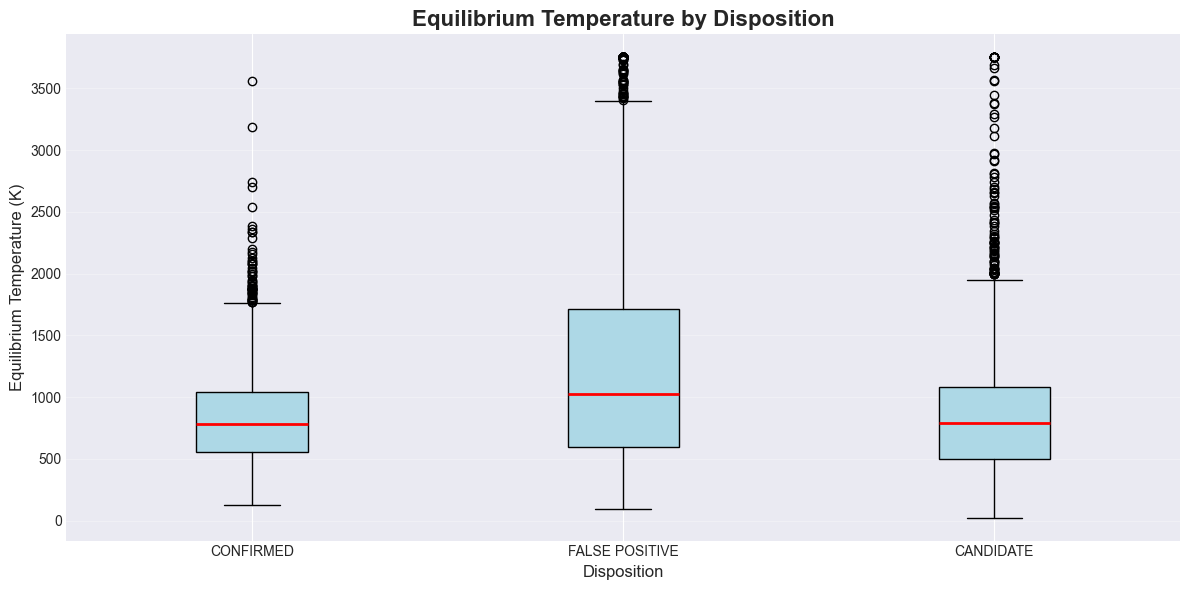

✓ Saved: 06_teq_by_disposition_boxplot.png


In [11]:
if 'koi_teq' in df_clean.columns and 'koi_disposition' in df_clean.columns:
    plt.figure(figsize=(12, 6))
    dispositions = df_clean['koi_disposition'].unique()
    data_to_plot = [df_clean[df_clean['koi_disposition'] == d]['koi_teq'].dropna() for d in dispositions]
    
    plt.boxplot(data_to_plot, labels=dispositions, patch_artist=True,
                boxprops=dict(facecolor='lightblue', color='black'),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='black'),
                capprops=dict(color='black'))
    plt.title('Equilibrium Temperature by Disposition', fontsize=16, fontweight='bold')
    plt.xlabel('Disposition', fontsize=12)
    plt.ylabel('Equilibrium Temperature (K)', fontsize=12)
    plt.grid(alpha=0.3, axis='y')
    plt.tight_layout()
    plt.savefig('visualizations/06_teq_by_disposition_boxplot.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 06_teq_by_disposition_boxplot.png")


### Figure 7: Transit Depth vs Duration

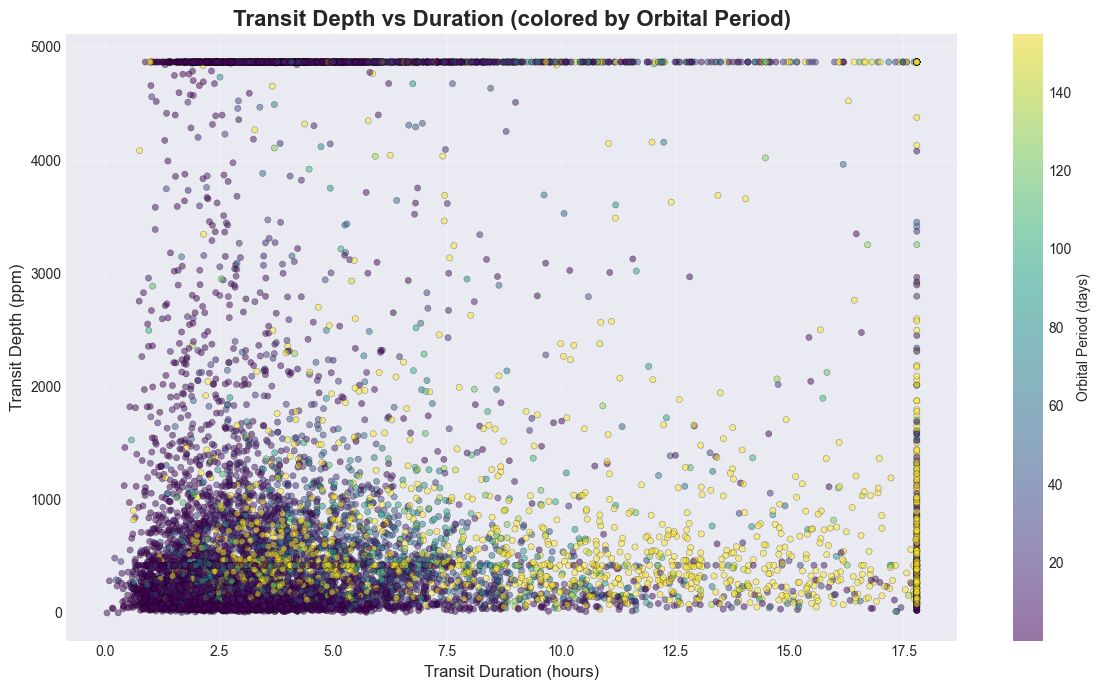

✓ Saved: 07_depth_vs_duration_scatter.png

✓ EDA visualizations complete!


In [12]:
if 'koi_depth' in df_clean.columns and 'koi_duration' in df_clean.columns:
    plt.figure(figsize=(12, 7))
    plt.scatter(df_clean['koi_duration'], df_clean['koi_depth'], 
               alpha=0.5, s=20, c=df_clean['koi_period'], cmap='viridis', edgecolors='black', linewidth=0.3)
    plt.colorbar(label='Orbital Period (days)')
    plt.title('Transit Depth vs Duration (colored by Orbital Period)', fontsize=16, fontweight='bold')
    plt.xlabel('Transit Duration (hours)', fontsize=12)
    plt.ylabel('Transit Depth (ppm)', fontsize=12)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('visualizations/07_depth_vs_duration_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 07_depth_vs_duration_scatter.png")

print("\n✓ EDA visualizations complete!")


## Section 4: Classification Model Development (8 Models)

In [13]:
if 'koi_disposition' in df_clean.columns:
    print("Preparing data for classification modeling...\n")
    
    # Encode target variable - Focus on binary classification (CONFIRMED vs others)
    df_model = df_clean.copy()
    df_model['target'] = (df_model['koi_disposition'] == 'CONFIRMED').astype(int)
    
    print("Target Distribution:")
    print(df_model['target'].value_counts())
    print(f"  0: Not Confirmed (FALSE POSITIVE + CANDIDATE)")
    print(f"  1: Confirmed Exoplanet\n")
    
    # Prepare features
    feature_cols = [col for col in df_model.columns if col not in ['koi_disposition', 'target']]
    X = df_model[feature_cols].copy()
    y = df_model['target']
    
    # Handle any remaining NaN/Inf from engineered features
    X.replace([np.inf, -np.inf], np.nan, inplace=True)
    X.fillna(X.median(), inplace=True)
    X.fillna(0, inplace=True)  # Fallback for columns where median is NaN
    
    # Drop constant columns (zero variance causes NaN in StandardScaler)
    constant_cols = [c for c in X.columns if X[c].nunique() <= 1]
    if constant_cols:
        X = X.drop(columns=constant_cols)
        feature_cols = [c for c in feature_cols if c not in constant_cols]
        print(f"  Dropped {len(constant_cols)} constant-value columns")
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
    print(f"Training set: {X_train.shape[0]:,} samples")
    print(f"Test set: {X_test.shape[0]:,} samples\n")
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Final NaN safety check (in case scaler produces NaN)
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)
    
    # Dictionary to store model results
    model_results = {}
    
    # ------- Helper function to train, evaluate & store results -------
    def evaluate_classifier(name, model, X_tr, X_te, y_tr, y_te, use_proba=True):
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        if use_proba:
            y_proba = model.predict_proba(X_te)[:, 1]
        else:
            y_proba = model.decision_function(X_te)
        acc  = accuracy_score(y_te, y_pred)
        prec = precision_score(y_te, y_pred)
        rec  = recall_score(y_te, y_pred)
        f1   = f1_score(y_te, y_pred)
        auc  = roc_auc_score(y_te, y_proba)
        
        print(f"\nPerformance Metrics:")
        print(f"  Accuracy:  {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall:    {rec:.4f}")
        print(f"  F1-Score:  {f1:.4f}")
        print(f"  ROC-AUC:   {auc:.4f}")
        
        model_results[name] = {
            'model': model,
            'predictions': y_pred,
            'probabilities': y_proba,
            'accuracy': acc,
            'precision': prec,
            'recall': rec,
            'f1': f1,
            'roc_auc': auc
        }


Preparing data for classification modeling...

Target Distribution:
target
0    7271
1    2293
Name: count, dtype: int64
  0: Not Confirmed (FALSE POSITIVE + CANDIDATE)
  1: Confirmed Exoplanet

Training set: 7,651 samples
Test set: 1,913 samples



In [14]:
    print("-" * 80)
    print("Model 1: Logistic Regression (Baseline)")
    print("-" * 80)
    evaluate_classifier('Logistic Regression',
                        LogisticRegression(random_state=42, max_iter=1000),
                        X_train_scaled, X_test_scaled, y_train, y_test)


--------------------------------------------------------------------------------
Model 1: Logistic Regression (Baseline)
--------------------------------------------------------------------------------

Performance Metrics:
  Accuracy:  0.8662
  Precision: 0.6678
  Recall:    0.8802
  F1-Score:  0.7594
  ROC-AUC:   0.9271


In [15]:
    print("\n" + "-" * 80)
    print("Model 2: Random Forest Classifier")
    print("-" * 80)
    evaluate_classifier('Random Forest',
                        RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
                        X_train, X_test, y_train, y_test)  # RF doesn't need scaling
    
    # Feature Importance from Random Forest
    rf_model = model_results['Random Forest']['model']
    print("\nTop 10 Most Important Features:")
    feature_importance = pd.DataFrame({
        'feature': feature_cols,
        'importance': rf_model.feature_importances_
    }).sort_values('importance', ascending=False)
    print(feature_importance.head(10).to_string(index=False))



--------------------------------------------------------------------------------
Model 2: Random Forest Classifier
--------------------------------------------------------------------------------

Performance Metrics:
  Accuracy:  0.8782
  Precision: 0.7374
  Recall:    0.7647
  F1-Score:  0.7508
  ROC-AUC:   0.9444

Top 10 Most Important Features:
                 feature  importance
               koi_score    0.354846
                koi_prad    0.088459
planet_star_radius_ratio    0.070176
            koi_duration    0.064485
               koi_depth    0.062114
     period_temp_product    0.053621
              koi_period    0.049337
               koi_insol    0.044244
                      ra    0.043796
                 koi_teq    0.043581


In [16]:
    print("\n" + "-" * 80)
    print("Model 3: Gradient Boosting Classifier")
    print("-" * 80)
    evaluate_classifier('Gradient Boosting',
                        GradientBoostingClassifier(n_estimators=100, random_state=42),
                        X_train, X_test, y_train, y_test)



--------------------------------------------------------------------------------
Model 3: Gradient Boosting Classifier
--------------------------------------------------------------------------------

Performance Metrics:
  Accuracy:  0.8808
  Precision: 0.7251
  Recall:    0.8105
  F1-Score:  0.7654
  ROC-AUC:   0.9440


In [17]:
    print("\n" + "-" * 80)
    print("Model 4: K-Nearest Neighbors (KNN)")
    print("-" * 80)
    evaluate_classifier('KNN',
                        KNeighborsClassifier(n_neighbors=7, n_jobs=-1),
                        X_train_scaled, X_test_scaled, y_train, y_test)



--------------------------------------------------------------------------------
Model 4: K-Nearest Neighbors (KNN)
--------------------------------------------------------------------------------

Performance Metrics:
  Accuracy:  0.8589
  Precision: 0.6728
  Recall:    0.8017
  F1-Score:  0.7316
  ROC-AUC:   0.9170


In [18]:
    print("\n" + "-" * 80)
    print("Model 5: Neural Network (MLP)")
    print("-" * 80)
    evaluate_classifier('Neural Network (MLP)',
                        MLPClassifier(hidden_layer_sizes=(128, 64, 32),
                                      max_iter=500, random_state=42,
                                      early_stopping=True, validation_fraction=0.1),
                        X_train_scaled, X_test_scaled, y_train, y_test)



--------------------------------------------------------------------------------
Model 5: Neural Network (MLP)
--------------------------------------------------------------------------------

Performance Metrics:
  Accuracy:  0.8819
  Precision: 0.7107
  Recall:    0.8562
  F1-Score:  0.7767
  ROC-AUC:   0.9397


In [19]:
    print("\n" + "-" * 80)
    print("Model 6: Support Vector Machine (SVM)")
    print("-" * 80)
    evaluate_classifier('SVM',
                        SVC(kernel='rbf', probability=True, random_state=42),
                        X_train_scaled, X_test_scaled, y_train, y_test)



--------------------------------------------------------------------------------
Model 6: Support Vector Machine (SVM)
--------------------------------------------------------------------------------

Performance Metrics:
  Accuracy:  0.8787
  Precision: 0.6901
  Recall:    0.8976
  F1-Score:  0.7803
  ROC-AUC:   0.9398


In [20]:
    print("\n" + "-" * 80)
    print("Model 7: LightGBM Classifier")
    print("-" * 80)
    evaluate_classifier('LightGBM',
                        LGBMClassifier(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),
                        X_train, X_test, y_train, y_test)



--------------------------------------------------------------------------------
Model 7: LightGBM Classifier
--------------------------------------------------------------------------------

Performance Metrics:
  Accuracy:  0.8871
  Precision: 0.7537
  Recall:    0.7865
  F1-Score:  0.7697
  ROC-AUC:   0.9486


In [21]:
    print("\n" + "-" * 80)
    print("Model 8: Voting Ensemble (Soft Voting of all 7 base models)")
    print("-" * 80)
    
    # Build fresh instances for the ensemble (sklearn requires unfitted estimators)
    voting_clf = VotingClassifier(
        estimators=[
            ('lr',  LogisticRegression(random_state=42, max_iter=1000)),
            ('rf',  RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
            ('gb',  GradientBoostingClassifier(n_estimators=100, random_state=42)),
            ('knn', KNeighborsClassifier(n_neighbors=7)),
            ('mlp', MLPClassifier(hidden_layer_sizes=(128, 64, 32), max_iter=500,
                                  random_state=42, early_stopping=True, validation_fraction=0.1)),
            ('svm', SVC(kernel='rbf', probability=True, random_state=42)),
            ('lgb', LGBMClassifier(n_estimators=100, random_state=42, verbose=-1))
        ],
        voting='soft',
        n_jobs=-1
    )
    evaluate_classifier('Voting Ensemble', voting_clf,
                        X_train_scaled, X_test_scaled, y_train, y_test)
    
    # =====================================================================
    # Classification Model Comparison Summary
    # =====================================================================
    print("\n\n" + "="*80)
    print("CLASSIFICATION MODEL COMPARISON SUMMARY")
    print("="*80)
    
    summary_df = pd.DataFrame({
        name: {k: v for k, v in res.items() if k not in ['model', 'predictions', 'probabilities']}
        for name, res in model_results.items()
    }).T.sort_values('roc_auc', ascending=False)
    
    print("\n" + summary_df.to_string())
    
    best_clf_name = summary_df.index[0]
    print(f"\n★ Best Classification Model: {best_clf_name} "
          f"(ROC-AUC = {summary_df.loc[best_clf_name, 'roc_auc']:.4f})")



--------------------------------------------------------------------------------
Model 8: Voting Ensemble (Soft Voting of all 7 base models)
--------------------------------------------------------------------------------

Performance Metrics:
  Accuracy:  0.8923
  Precision: 0.7373
  Recall:    0.8562
  F1-Score:  0.7923
  ROC-AUC:   0.9497


CLASSIFICATION MODEL COMPARISON SUMMARY

                      accuracy  precision    recall        f1   roc_auc
Voting Ensemble       0.892316   0.737336  0.856209  0.792339  0.949689
LightGBM              0.887088   0.753653  0.786492  0.769723  0.948605
Random Forest         0.878202   0.737395  0.764706  0.750802  0.944357
Gradient Boosting     0.880815   0.725146  0.810458  0.765432  0.943968
SVM                   0.878725   0.690117  0.897603  0.780303  0.939831
Neural Network (MLP)  0.881861   0.710669  0.856209  0.776680  0.939722
Logistic Regression   0.866179   0.667769  0.880174  0.759398  0.927120
KNN                   0.858860   0.6

In [22]:
    # Classification Visualizations
    # =====================================================================
    print("\n\nGenerating classification visualizations...")




Generating classification visualizations...


### Figure 8: All-Model Metric Comparison Bar Chart

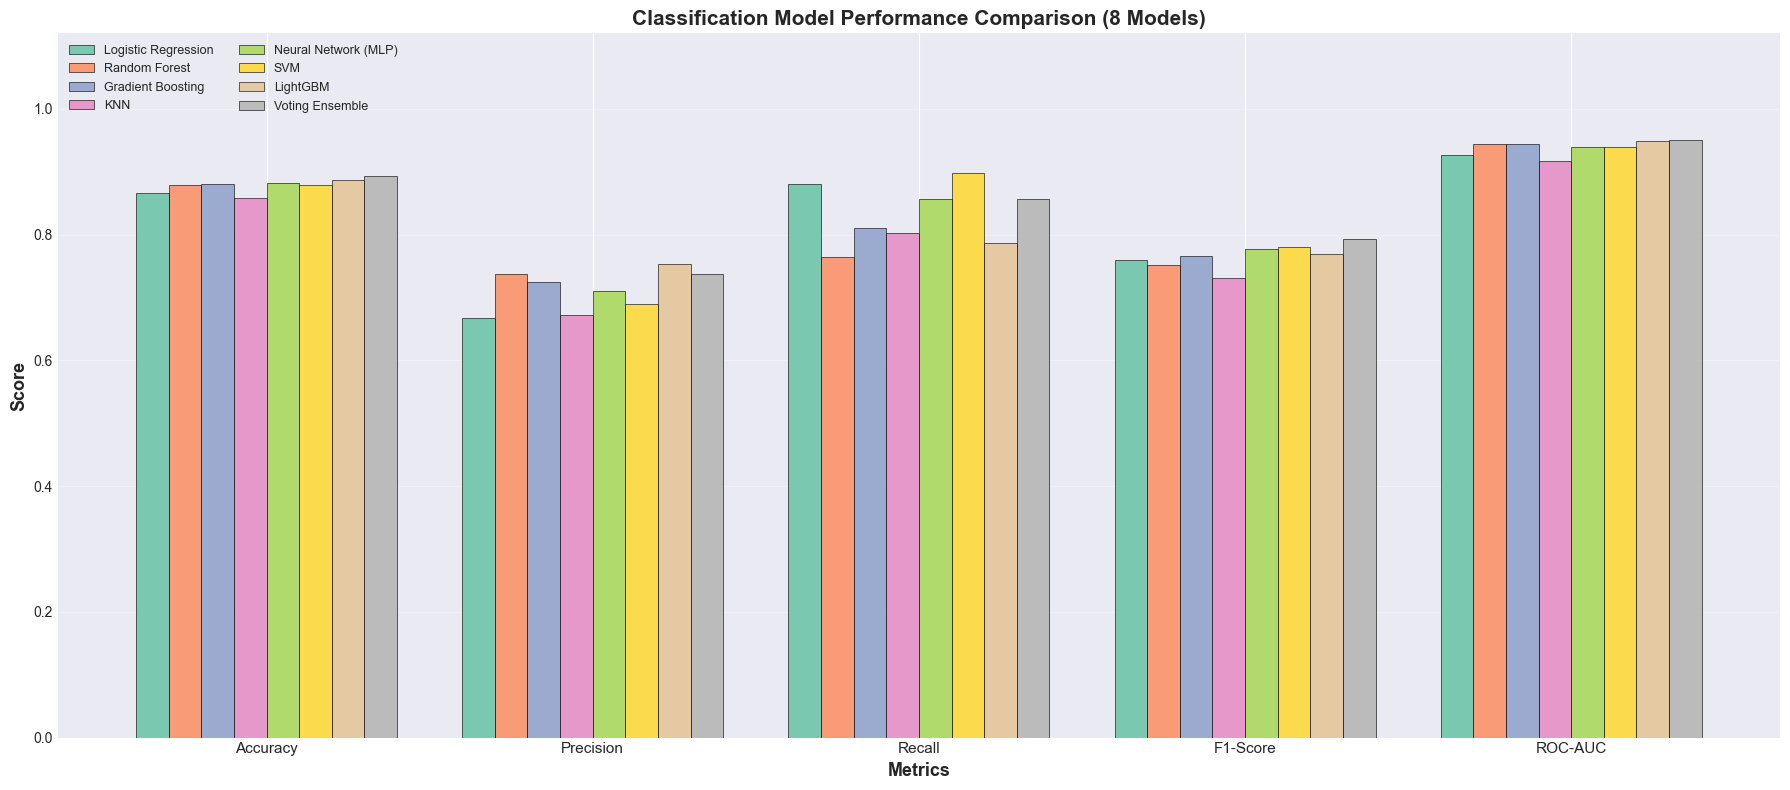

✓ Saved: 08_classification_model_comparison.png


In [23]:
    clf_metrics = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    clf_names = list(model_results.keys())
    n_models = len(clf_names)
    
    fig, ax = plt.subplots(figsize=(18, 8))
    x = np.arange(len(clf_metrics))
    width = 0.8 / n_models
    colors = plt.cm.Set2(np.linspace(0, 1, n_models))
    
    for i, name in enumerate(clf_names):
        values = [model_results[name][m] for m in clf_metrics]
        bars = ax.bar(x + i*width, values, width, label=name, alpha=0.85,
                      edgecolor='black', linewidth=0.5, color=colors[i])
    
    ax.set_xlabel('Metrics', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score', fontsize=13, fontweight='bold')
    ax.set_title('Classification Model Performance Comparison (8 Models)',
                 fontsize=15, fontweight='bold')
    ax.set_xticks(x + width * (n_models - 1) / 2)
    ax.set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'],
                       fontsize=11)
    ax.legend(loc='upper left', fontsize=9, ncol=2)
    ax.grid(alpha=0.3, axis='y')
    ax.set_ylim([0, 1.12])
    plt.tight_layout()
    plt.savefig('visualizations/08_classification_model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 08_classification_model_comparison.png")


### Figure 9: Confusion Matrices for all 8 models

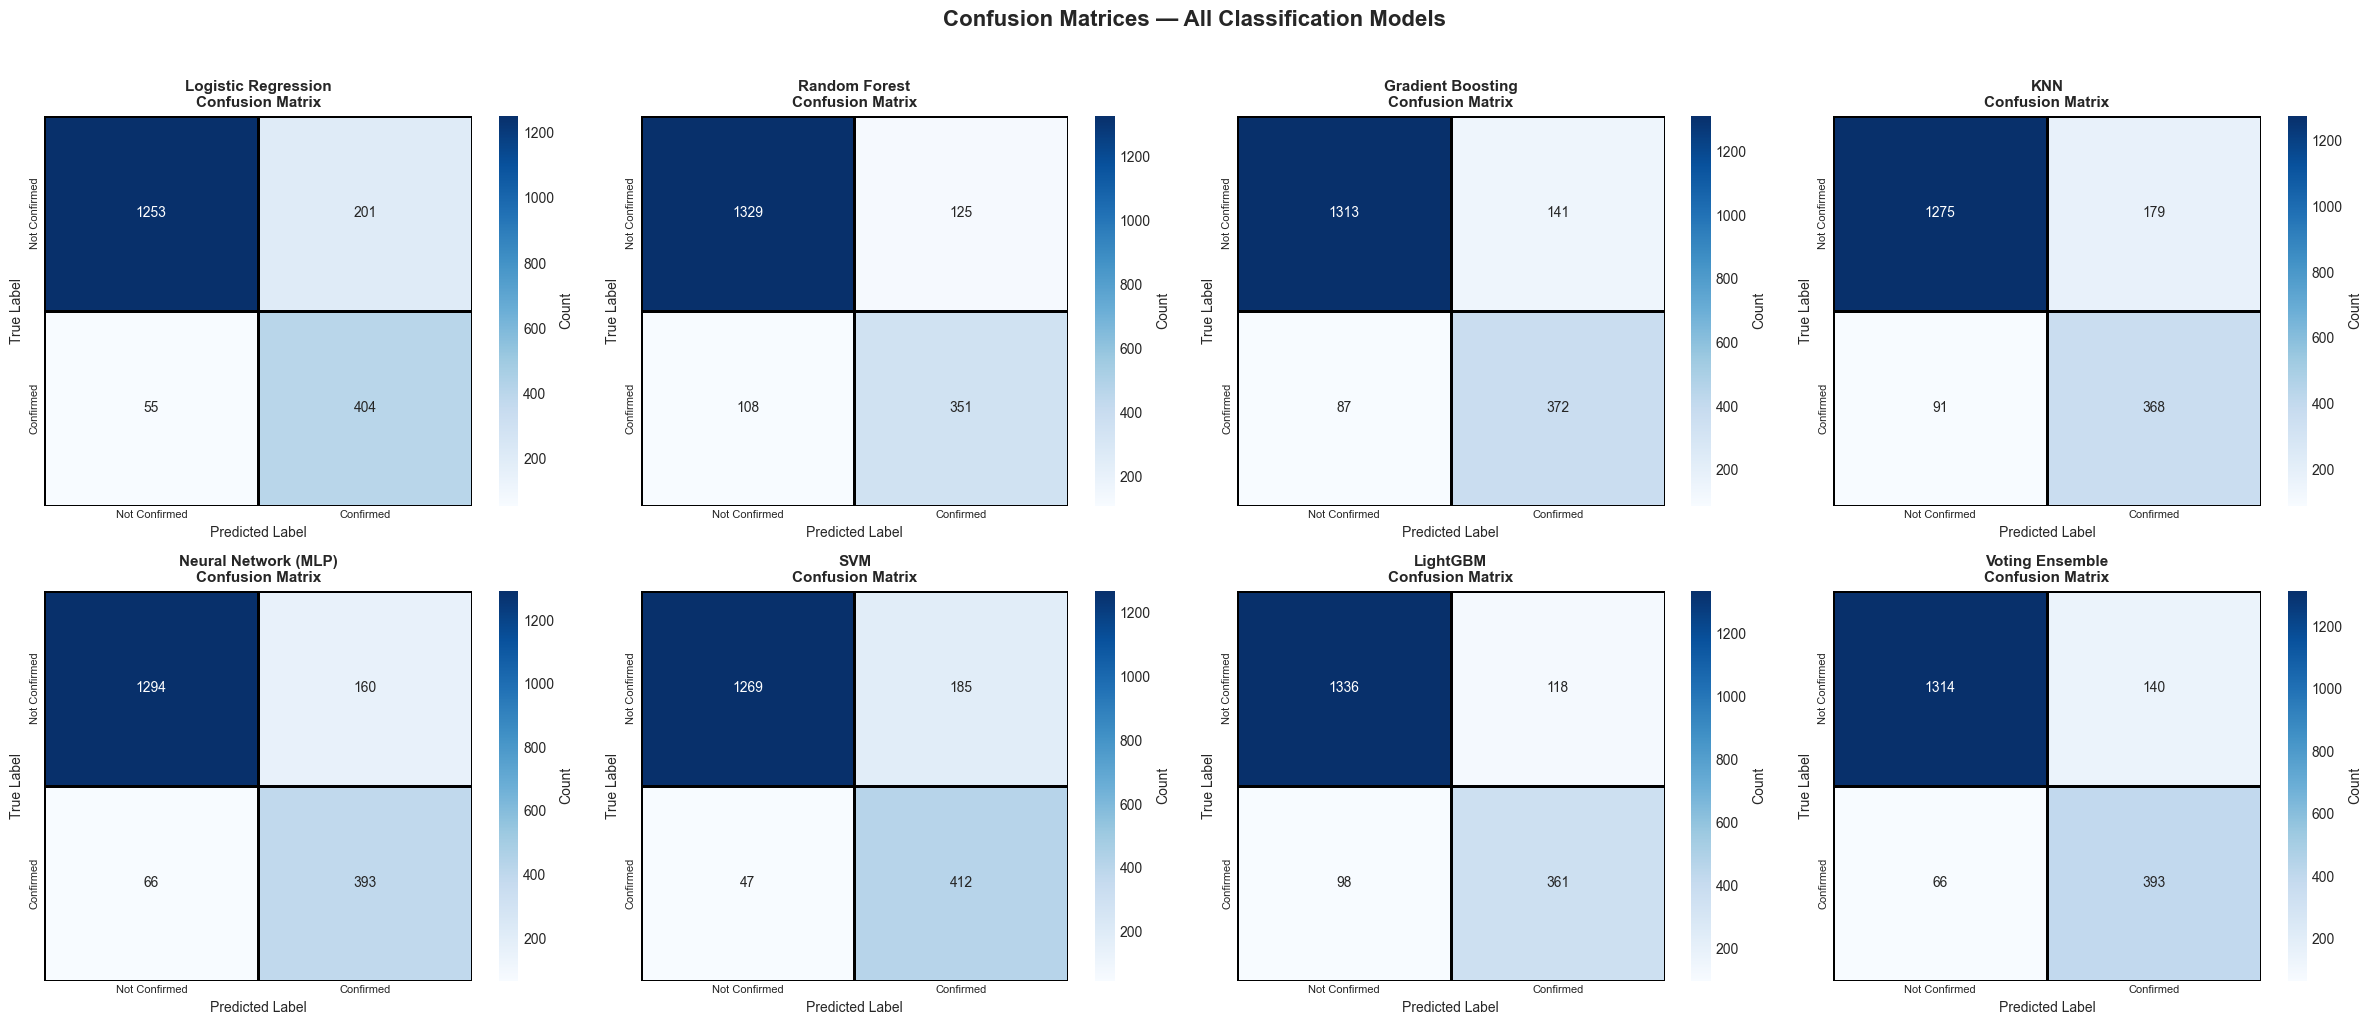

✓ Saved: 09_confusion_matrices.png


In [24]:
    n_rows = 2
    n_cols = 4
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 10))
    axes_flat = axes.flatten()
    
    for idx, name in enumerate(clf_names):
        cm = confusion_matrix(y_test, model_results[name]['predictions'])
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes_flat[idx],
                    cbar_kws={'label': 'Count'}, linewidths=1, linecolor='black')
        axes_flat[idx].set_title(f'{name}\nConfusion Matrix', fontsize=11, fontweight='bold')
        axes_flat[idx].set_ylabel('True Label', fontsize=10)
        axes_flat[idx].set_xlabel('Predicted Label', fontsize=10)
        axes_flat[idx].set_xticklabels(['Not Confirmed', 'Confirmed'], fontsize=8)
        axes_flat[idx].set_yticklabels(['Not Confirmed', 'Confirmed'], fontsize=8)
    
    plt.suptitle('Confusion Matrices — All Classification Models', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('visualizations/09_confusion_matrices.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 09_confusion_matrices.png")


### Figure 10: Feature Importance (Random Forest)

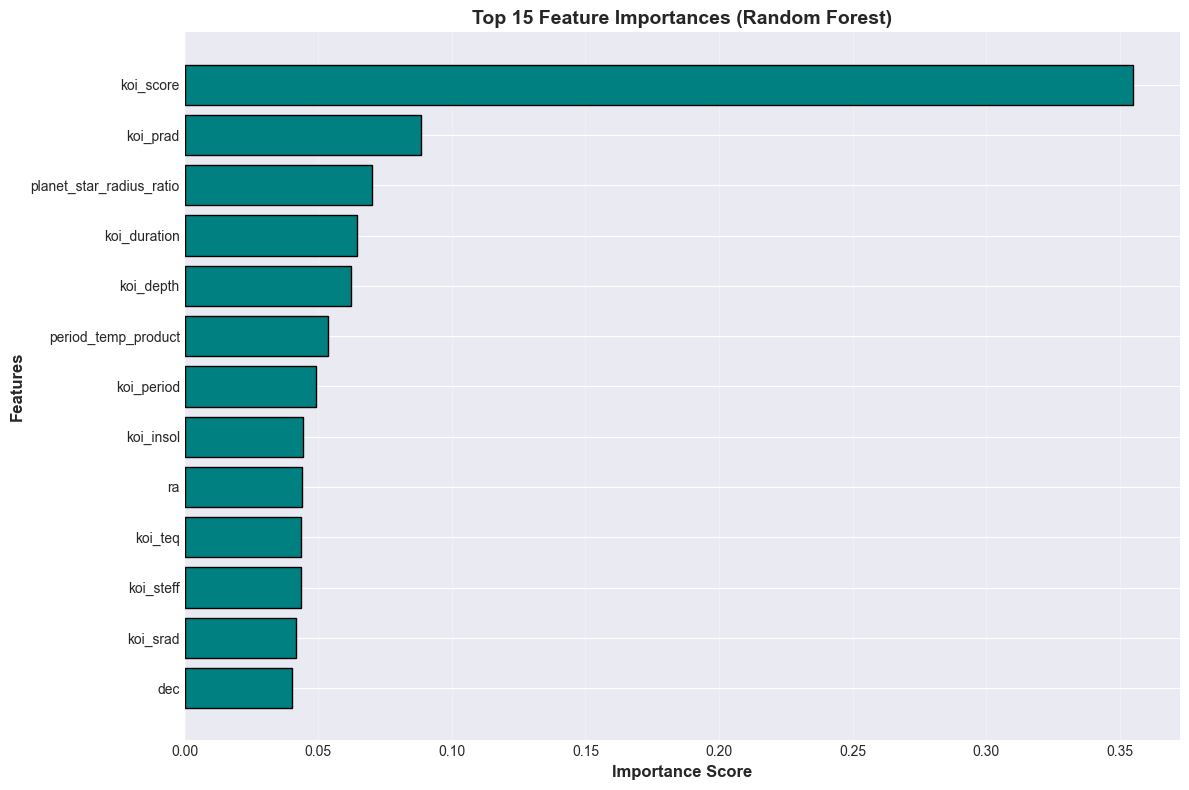

✓ Saved: 10_feature_importance.png


In [25]:
    plt.figure(figsize=(12, 8))
    top_features = feature_importance.head(15)
    plt.barh(range(len(top_features)), top_features['importance'], color='teal', edgecolor='black')
    plt.yticks(range(len(top_features)), top_features['feature'])
    plt.xlabel('Importance Score', fontsize=12, fontweight='bold')
    plt.ylabel('Features', fontsize=12, fontweight='bold')
    plt.title('Top 15 Feature Importances (Random Forest)', fontsize=14, fontweight='bold')
    plt.gca().invert_yaxis()
    plt.grid(alpha=0.3, axis='x')
    plt.tight_layout()
    plt.savefig('visualizations/10_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 10_feature_importance.png")


### Figure 11: ROC Curves for all 8 models

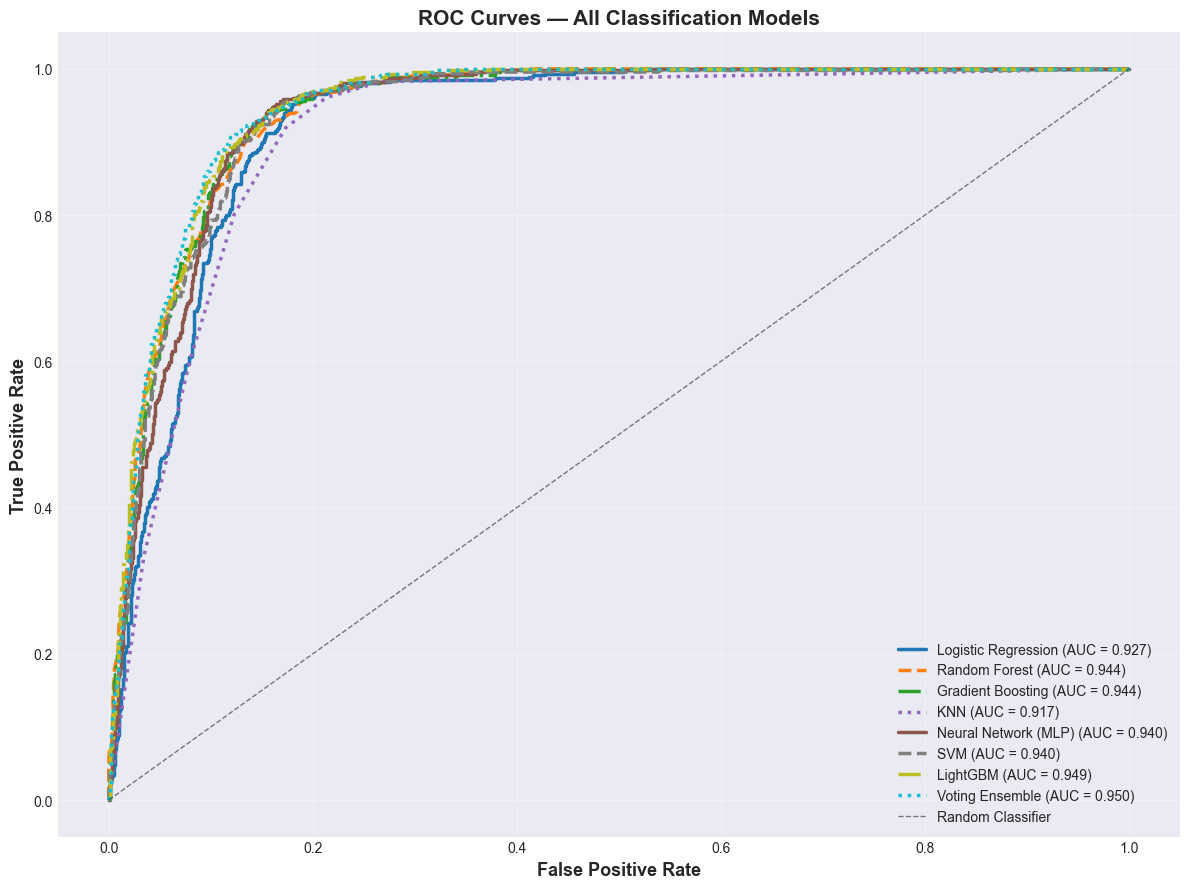

✓ Saved: 11_roc_curves.png

✓ Classification analysis complete! (8 models trained & evaluated)


In [26]:
    plt.figure(figsize=(12, 9))
    line_styles = ['-', '--', '-.', ':', '-', '--', '-.', ':']
    colors_roc = plt.cm.tab10(np.linspace(0, 1, n_models))
    
    for i, name in enumerate(clf_names):
        proba = model_results[name]['probabilities']
        fpr, tpr, _ = roc_curve(y_test, proba)
        auc_val = model_results[name]['roc_auc']
        plt.plot(fpr, tpr, linewidth=2.5, label=f'{name} (AUC = {auc_val:.3f})',
                 color=colors_roc[i], linestyle=line_styles[i % len(line_styles)])
    
    plt.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
    plt.xlabel('False Positive Rate', fontsize=13, fontweight='bold')
    plt.ylabel('True Positive Rate', fontsize=13, fontweight='bold')
    plt.title('ROC Curves — All Classification Models', fontsize=15, fontweight='bold')
    plt.legend(loc='lower right', fontsize=10)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig('visualizations/11_roc_curves.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 11_roc_curves.png")
    
    print("\n✓ Classification analysis complete! (8 models trained & evaluated)")


## Section 5: Regression Model Development (8 Models)

In [27]:
if 'koi_disposition' in df_clean.columns and 'koi_prad' in df_clean.columns:
    print("Preparing data for regression modeling...\n")
    
    # Use only CONFIRMED exoplanets for radius prediction
    df_reg = df_clean[df_clean['koi_disposition'] == 'CONFIRMED'].copy()
    
    # Features: everything except disposition, target, and the target variable itself
    reg_feature_cols = [c for c in df_reg.columns if c not in ['koi_disposition', 'koi_prad']]
    
    X_reg = df_reg[reg_feature_cols].copy()
    y_reg = df_reg['koi_prad'].copy()
    
    # Handle any remaining NaN/Inf from engineered features
    X_reg.replace([np.inf, -np.inf], np.nan, inplace=True)
    X_reg.fillna(X_reg.median(), inplace=True)
    X_reg.fillna(0, inplace=True)
    
    # Drop any rows where target is NaN
    valid_mask = y_reg.notna()
    X_reg = X_reg.loc[valid_mask].reset_index(drop=True)
    y_reg = y_reg.loc[valid_mask].reset_index(drop=True)
    
    # Drop constant columns
    constant_reg_cols = [c for c in X_reg.columns if X_reg[c].nunique() <= 1]
    if constant_reg_cols:
        X_reg = X_reg.drop(columns=constant_reg_cols)
        reg_feature_cols = [c for c in reg_feature_cols if c not in constant_reg_cols]
    
    print(f"Regression dataset: {len(X_reg):,} confirmed exoplanet samples")
    print(f"Target: koi_prad (Planetary Radius in Earth Radii)")
    print(f"  Mean radius:   {y_reg.mean():.3f}")
    print(f"  Median radius: {y_reg.median():.3f}")
    print(f"  Std deviation: {y_reg.std():.3f}\n")
    
    # Split
    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )
    print(f"Training set: {X_reg_train.shape[0]:,} samples")
    print(f"Test set:     {X_reg_test.shape[0]:,} samples\n")
    
    # Scale
    reg_scaler = StandardScaler()
    X_reg_train_scaled = reg_scaler.fit_transform(X_reg_train)
    X_reg_test_scaled  = reg_scaler.transform(X_reg_test)
    X_reg_train_scaled = np.nan_to_num(X_reg_train_scaled, nan=0.0)
    X_reg_test_scaled  = np.nan_to_num(X_reg_test_scaled, nan=0.0)
    
    # Dictionary to store regression results
    reg_results = {}
    
    # ------- Helper function for regression -------
    def evaluate_regressor(name, model, X_tr, X_te, y_tr, y_te):
        model.fit(X_tr, y_tr)
        y_pred = model.predict(X_te)
        r2  = r2_score(y_te, y_pred)
        mae = mean_absolute_error(y_te, y_pred)
        rmse = np.sqrt(mean_squared_error(y_te, y_pred))
        
        print(f"\nPerformance Metrics:")
        print(f"  R² Score:  {r2:.4f}")
        print(f"  MAE:       {mae:.4f}")
        print(f"  RMSE:      {rmse:.4f}")
        
        reg_results[name] = {
            'model': model,
            'predictions': y_pred,
            'r2': r2,
            'mae': mae,
            'rmse': rmse
        }


Preparing data for regression modeling...

Regression dataset: 2,293 confirmed exoplanet samples
Target: koi_prad (Planetary Radius in Earth Radii)
  Mean radius:   2.854
  Median radius: 2.170
  Std deviation: 3.042

Training set: 1,834 samples
Test set:     459 samples



In [28]:
    print("-" * 80)
    print("Regressor 1: Linear Regression (Baseline)")
    print("-" * 80)
    evaluate_regressor('Linear Regression', LinearRegression(),
                       X_reg_train_scaled, X_reg_test_scaled, y_reg_train, y_reg_test)


--------------------------------------------------------------------------------
Regressor 1: Linear Regression (Baseline)
--------------------------------------------------------------------------------

Performance Metrics:
  R² Score:  0.9025
  MAE:       0.5213
  RMSE:      0.9958


In [29]:
    print("\n" + "-" * 80)
    print("Regressor 2: Ridge Regression")
    print("-" * 80)
    evaluate_regressor('Ridge Regression', Ridge(alpha=1.0, random_state=42),
                       X_reg_train_scaled, X_reg_test_scaled, y_reg_train, y_reg_test)



--------------------------------------------------------------------------------
Regressor 2: Ridge Regression
--------------------------------------------------------------------------------

Performance Metrics:
  R² Score:  0.9026
  MAE:       0.5206
  RMSE:      0.9953


In [30]:
    print("\n" + "-" * 80)
    print("Regressor 3: Lasso Regression")
    print("-" * 80)
    evaluate_regressor('Lasso Regression', Lasso(alpha=0.01, random_state=42, max_iter=5000),
                       X_reg_train_scaled, X_reg_test_scaled, y_reg_train, y_reg_test)



--------------------------------------------------------------------------------
Regressor 3: Lasso Regression
--------------------------------------------------------------------------------

Performance Metrics:
  R² Score:  0.9071
  MAE:       0.5023
  RMSE:      0.9722


In [31]:
    print("\n" + "-" * 80)
    print("Regressor 4: K-Nearest Neighbors Regressor")
    print("-" * 80)
    evaluate_regressor('KNN Regressor', KNeighborsRegressor(n_neighbors=7, n_jobs=-1),
                       X_reg_train_scaled, X_reg_test_scaled, y_reg_train, y_reg_test)



--------------------------------------------------------------------------------
Regressor 4: K-Nearest Neighbors Regressor
--------------------------------------------------------------------------------

Performance Metrics:
  R² Score:  0.8233
  MAE:       0.5294
  RMSE:      1.3405


In [32]:
    print("\n" + "-" * 80)
    print("Regressor 5: Random Forest Regressor")
    print("-" * 80)
    evaluate_regressor('Random Forest Regressor',
                       RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
                       X_reg_train, X_reg_test, y_reg_train, y_reg_test)



--------------------------------------------------------------------------------
Regressor 5: Random Forest Regressor
--------------------------------------------------------------------------------

Performance Metrics:
  R² Score:  0.8674
  MAE:       0.1826
  RMSE:      1.1611


In [33]:
    print("\n" + "-" * 80)
    print("Regressor 6: Gradient Boosting Regressor")
    print("-" * 80)
    evaluate_regressor('Gradient Boosting Regressor',
                       GradientBoostingRegressor(n_estimators=100, max_depth=5, random_state=42),
                       X_reg_train, X_reg_test, y_reg_train, y_reg_test)



--------------------------------------------------------------------------------
Regressor 6: Gradient Boosting Regressor
--------------------------------------------------------------------------------

Performance Metrics:
  R² Score:  0.9398
  MAE:       0.1472
  RMSE:      0.7821


In [34]:
    print("\n" + "-" * 80)
    print("Regressor 7: LightGBM Regressor")
    print("-" * 80)
    evaluate_regressor('LightGBM Regressor',
                       LGBMRegressor(n_estimators=100, random_state=42, verbose=-1, n_jobs=-1),
                       X_reg_train, X_reg_test, y_reg_train, y_reg_test)



--------------------------------------------------------------------------------
Regressor 7: LightGBM Regressor
--------------------------------------------------------------------------------

Performance Metrics:
  R² Score:  0.7824
  MAE:       0.2303
  RMSE:      1.4874


In [35]:
    print("\n" + "-" * 80)
    print("Regressor 8: Neural Network (MLP) Regressor")
    print("-" * 80)
    evaluate_regressor('Neural Network Regressor',
                       MLPRegressor(hidden_layer_sizes=(128, 64, 32), max_iter=500,
                                    random_state=42, early_stopping=True, validation_fraction=0.1),
                       X_reg_train_scaled, X_reg_test_scaled, y_reg_train, y_reg_test)
    
    # =====================================================================
    # Regression Model Comparison Summary
    # =====================================================================
    print("\n\n" + "="*80)
    print("REGRESSION MODEL COMPARISON SUMMARY")
    print("="*80)
    
    reg_summary_df = pd.DataFrame({
        name: {k: v for k, v in res.items() if k not in ['model', 'predictions']}
        for name, res in reg_results.items()
    }).T.sort_values('r2', ascending=False)
    
    print("\n" + reg_summary_df.to_string())
    
    best_reg_name = reg_summary_df.index[0]
    print(f"\n★ Best Regression Model: {best_reg_name} "
          f"(R² = {reg_summary_df.loc[best_reg_name, 'r2']:.4f})")



--------------------------------------------------------------------------------
Regressor 8: Neural Network (MLP) Regressor
--------------------------------------------------------------------------------

Performance Metrics:
  R² Score:  0.9085
  MAE:       0.5490
  RMSE:      0.9645


REGRESSION MODEL COMPARISON SUMMARY

                                   r2       mae      rmse
Gradient Boosting Regressor  0.939844  0.147159  0.782107
Neural Network Regressor     0.908513  0.549028  0.964514
Lasso Regression             0.907050  0.502255  0.972194
Ridge Regression             0.902579  0.520560  0.995303
Linear Regression            0.902473  0.521316  0.995842
Random Forest Regressor      0.867415  0.182626  1.161115
KNN Regressor                0.823271  0.529374  1.340546
LightGBM Regressor           0.782439  0.230271  1.487368

★ Best Regression Model: Gradient Boosting Regressor (R² = 0.9398)


In [36]:
    # Regression Visualizations
    # =====================================================================
    print("\n\nGenerating regression visualizations...")




Generating regression visualizations...


### Figure 12: Regression Model Comparison Bar Chart

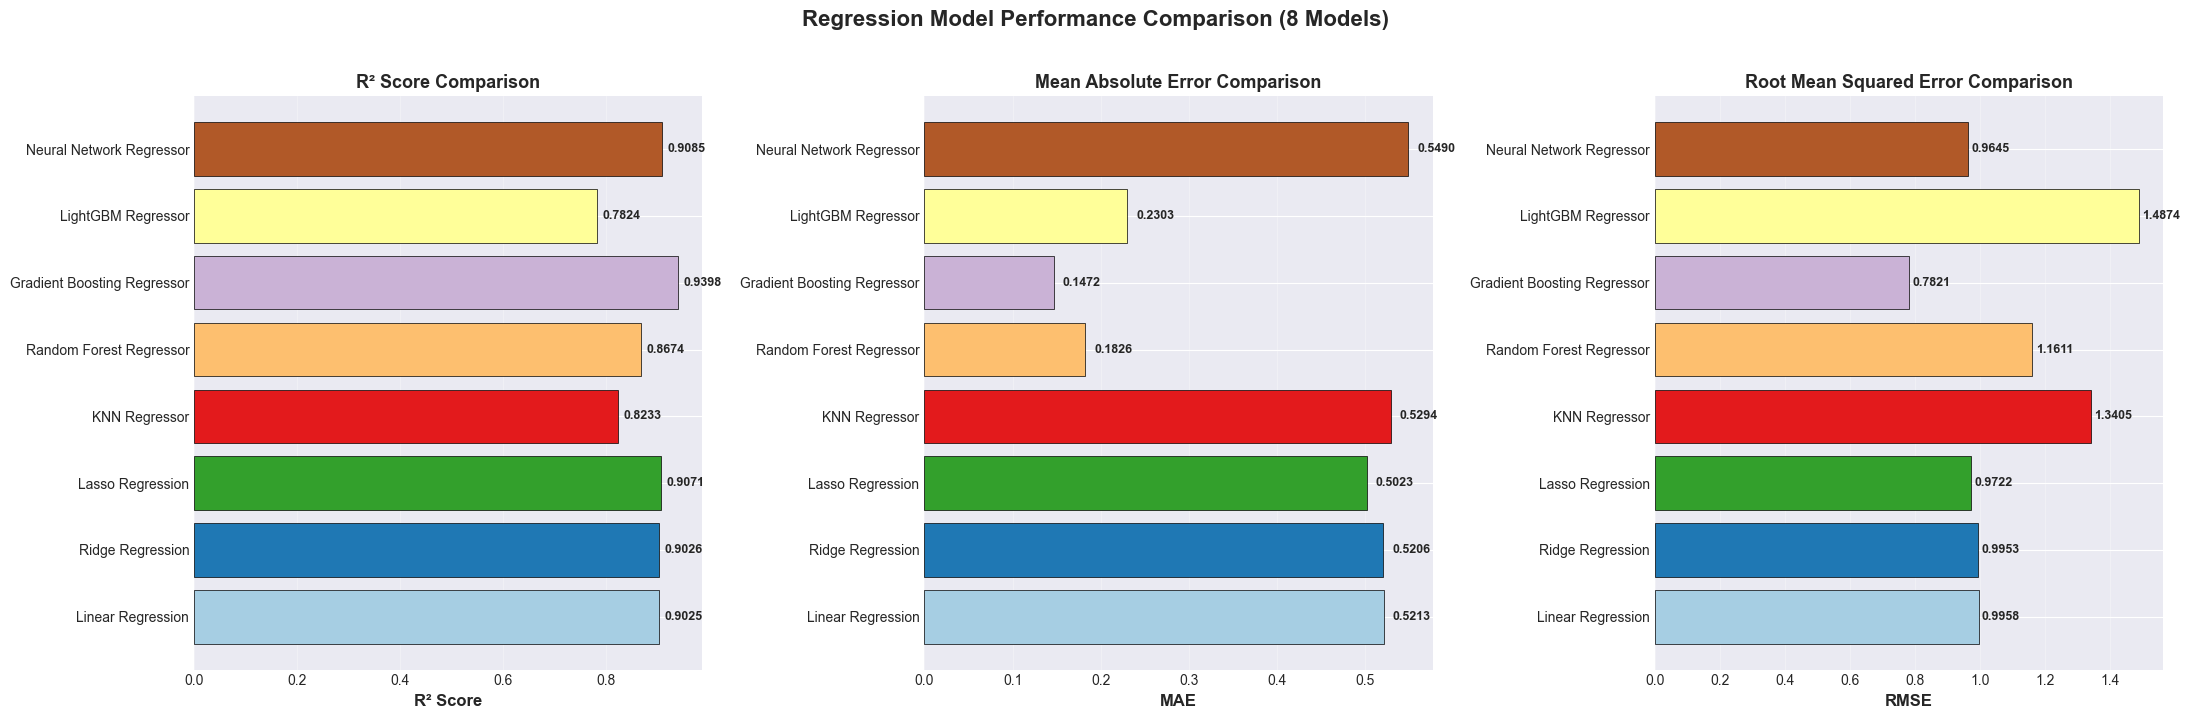

✓ Saved: 12_regression_model_comparison.png


In [37]:
    reg_names = list(reg_results.keys())
    n_reg = len(reg_names)
    
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))
    colors_reg = plt.cm.Paired(np.linspace(0, 1, n_reg))
    
    # R² comparison
    r2_vals = [reg_results[n]['r2'] for n in reg_names]
    bars = axes[0].barh(reg_names, r2_vals, color=colors_reg, edgecolor='black', linewidth=0.5)
    axes[0].set_xlabel('R² Score', fontsize=12, fontweight='bold')
    axes[0].set_title('R² Score Comparison', fontsize=13, fontweight='bold')
    axes[0].grid(alpha=0.3, axis='x')
    for bar, val in zip(bars, r2_vals):
        axes[0].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    
    # MAE comparison
    mae_vals = [reg_results[n]['mae'] for n in reg_names]
    bars = axes[1].barh(reg_names, mae_vals, color=colors_reg, edgecolor='black', linewidth=0.5)
    axes[1].set_xlabel('MAE', fontsize=12, fontweight='bold')
    axes[1].set_title('Mean Absolute Error Comparison', fontsize=13, fontweight='bold')
    axes[1].grid(alpha=0.3, axis='x')
    for bar, val in zip(bars, mae_vals):
        axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    
    # RMSE comparison
    rmse_vals = [reg_results[n]['rmse'] for n in reg_names]
    bars = axes[2].barh(reg_names, rmse_vals, color=colors_reg, edgecolor='black', linewidth=0.5)
    axes[2].set_xlabel('RMSE', fontsize=12, fontweight='bold')
    axes[2].set_title('Root Mean Squared Error Comparison', fontsize=13, fontweight='bold')
    axes[2].grid(alpha=0.3, axis='x')
    for bar, val in zip(bars, rmse_vals):
        axes[2].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                     f'{val:.4f}', va='center', fontsize=9, fontweight='bold')
    
    plt.suptitle('Regression Model Performance Comparison (8 Models)',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('visualizations/12_regression_model_comparison.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 12_regression_model_comparison.png")


### Figure 13: Actual vs Predicted (Top 4 regressors by R²)

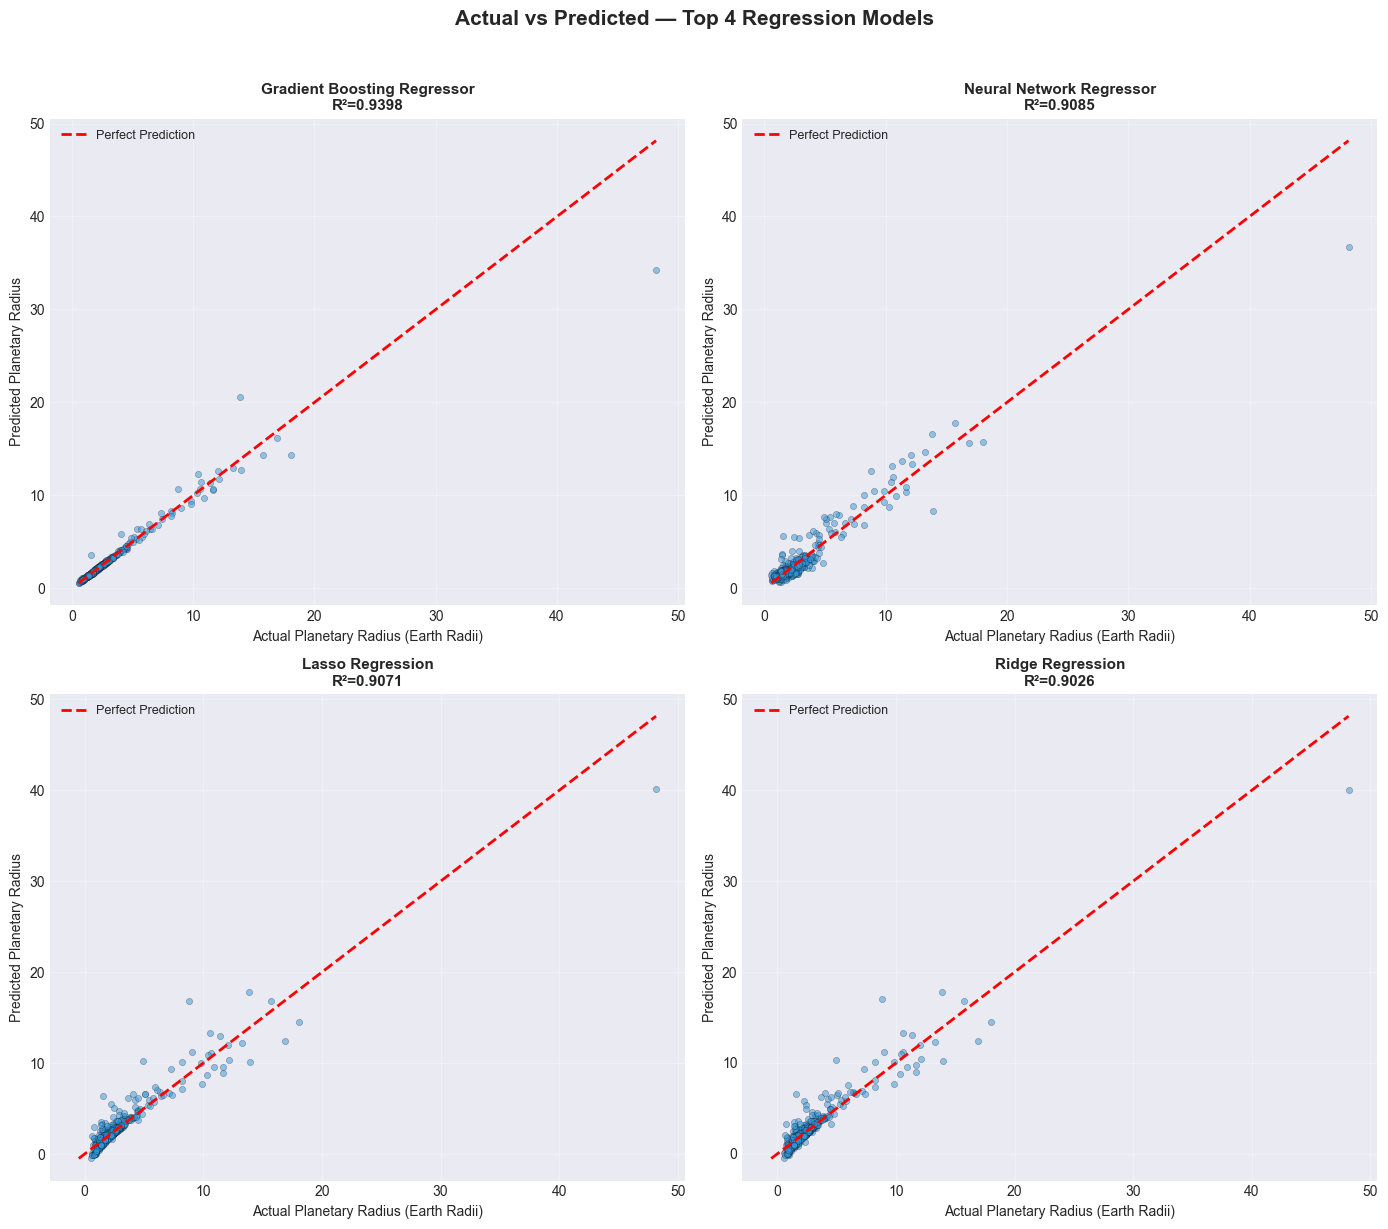

✓ Saved: 13_actual_vs_predicted.png


In [38]:
    top4 = reg_summary_df.index[:4].tolist()
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes_flat = axes.flatten()
    
    for idx, name in enumerate(top4):
        y_pred = reg_results[name]['predictions']
        ax = axes_flat[idx]
        ax.scatter(y_reg_test, y_pred, alpha=0.5, s=20, edgecolors='black', linewidth=0.3, c='#3498db')
        lims = [min(y_reg_test.min(), y_pred.min()), max(y_reg_test.max(), y_pred.max())]
        ax.plot(lims, lims, 'r--', linewidth=2, label='Perfect Prediction')
        ax.set_xlabel('Actual Planetary Radius (Earth Radii)', fontsize=10)
        ax.set_ylabel('Predicted Planetary Radius', fontsize=10)
        ax.set_title(f'{name}\nR²={reg_results[name]["r2"]:.4f}', fontsize=11, fontweight='bold')
        ax.legend(fontsize=9)
        ax.grid(alpha=0.3)
    
    plt.suptitle('Actual vs Predicted — Top 4 Regression Models',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('visualizations/13_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 13_actual_vs_predicted.png")


### Figure 14: Residual Analysis (Top 4 regressors)

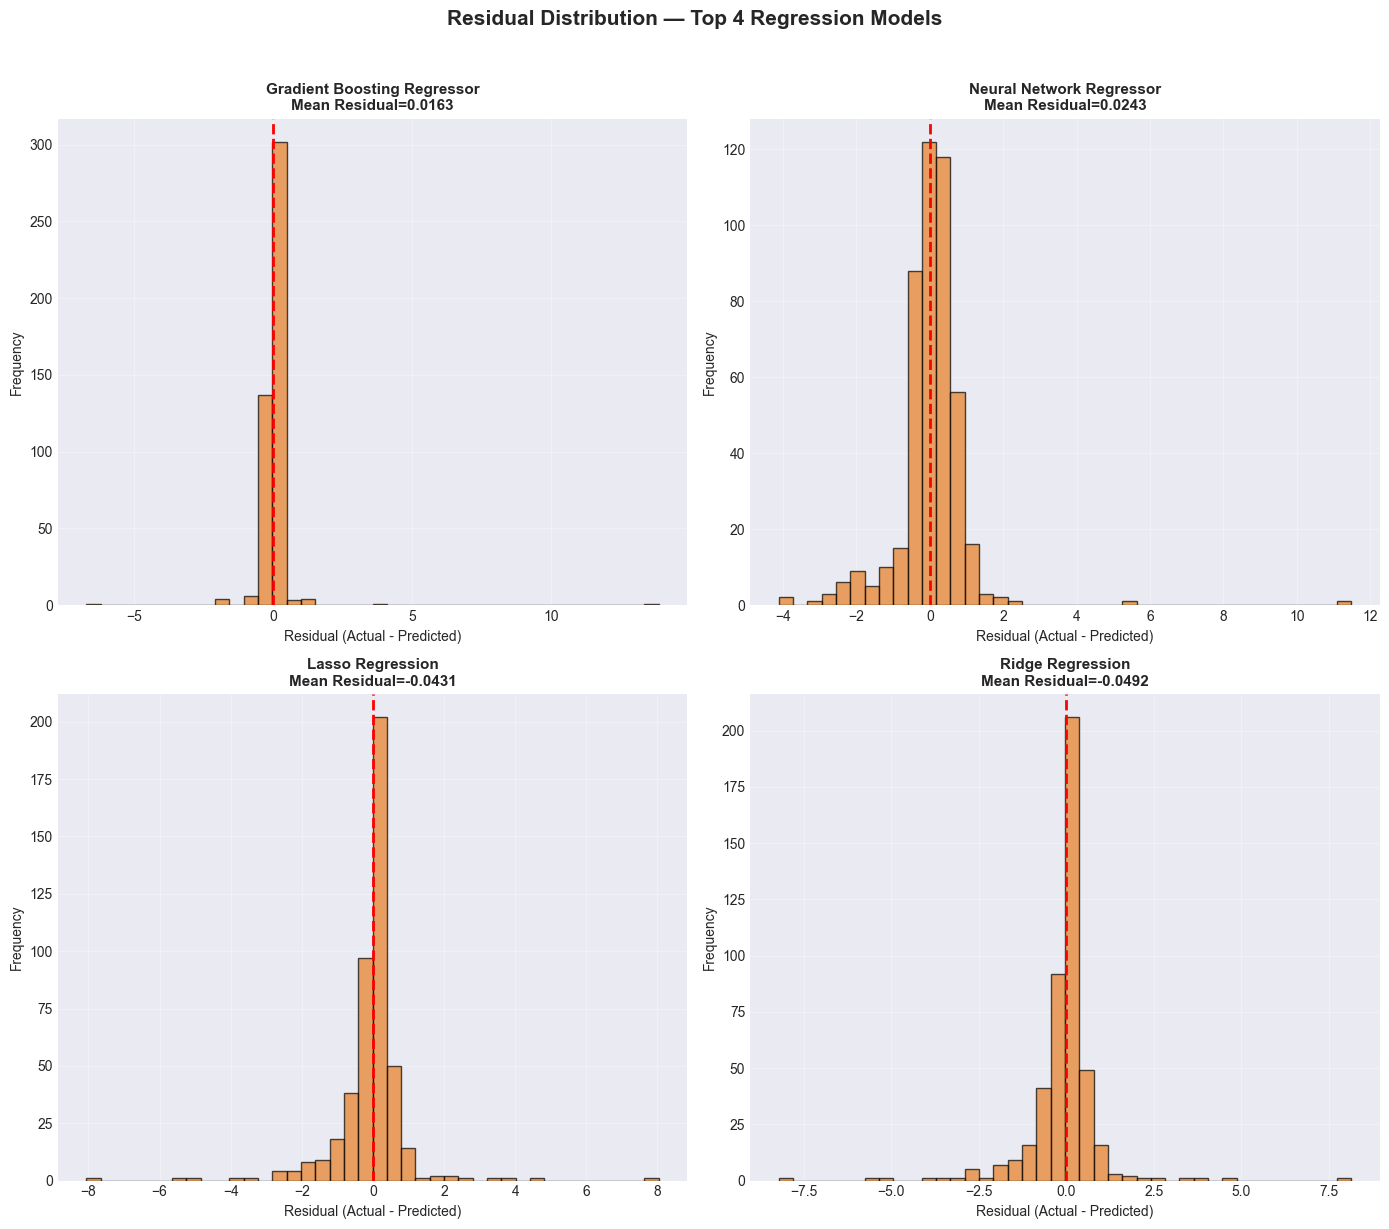

✓ Saved: 14_residual_analysis.png


In [39]:
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes_flat = axes.flatten()
    
    for idx, name in enumerate(top4):
        y_pred = reg_results[name]['predictions']
        residuals = y_reg_test.values - y_pred
        ax = axes_flat[idx]
        ax.hist(residuals, bins=40, color='#e67e22', edgecolor='black', alpha=0.7)
        ax.axvline(0, color='red', linestyle='--', linewidth=2)
        ax.set_xlabel('Residual (Actual - Predicted)', fontsize=10)
        ax.set_ylabel('Frequency', fontsize=10)
        ax.set_title(f'{name}\nMean Residual={np.mean(residuals):.4f}', fontsize=11, fontweight='bold')
        ax.grid(alpha=0.3)
    
    plt.suptitle('Residual Distribution — Top 4 Regression Models',
                 fontsize=15, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('visualizations/14_residual_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 14_residual_analysis.png")


### Figure 15: Complete Model Summary Heatmap

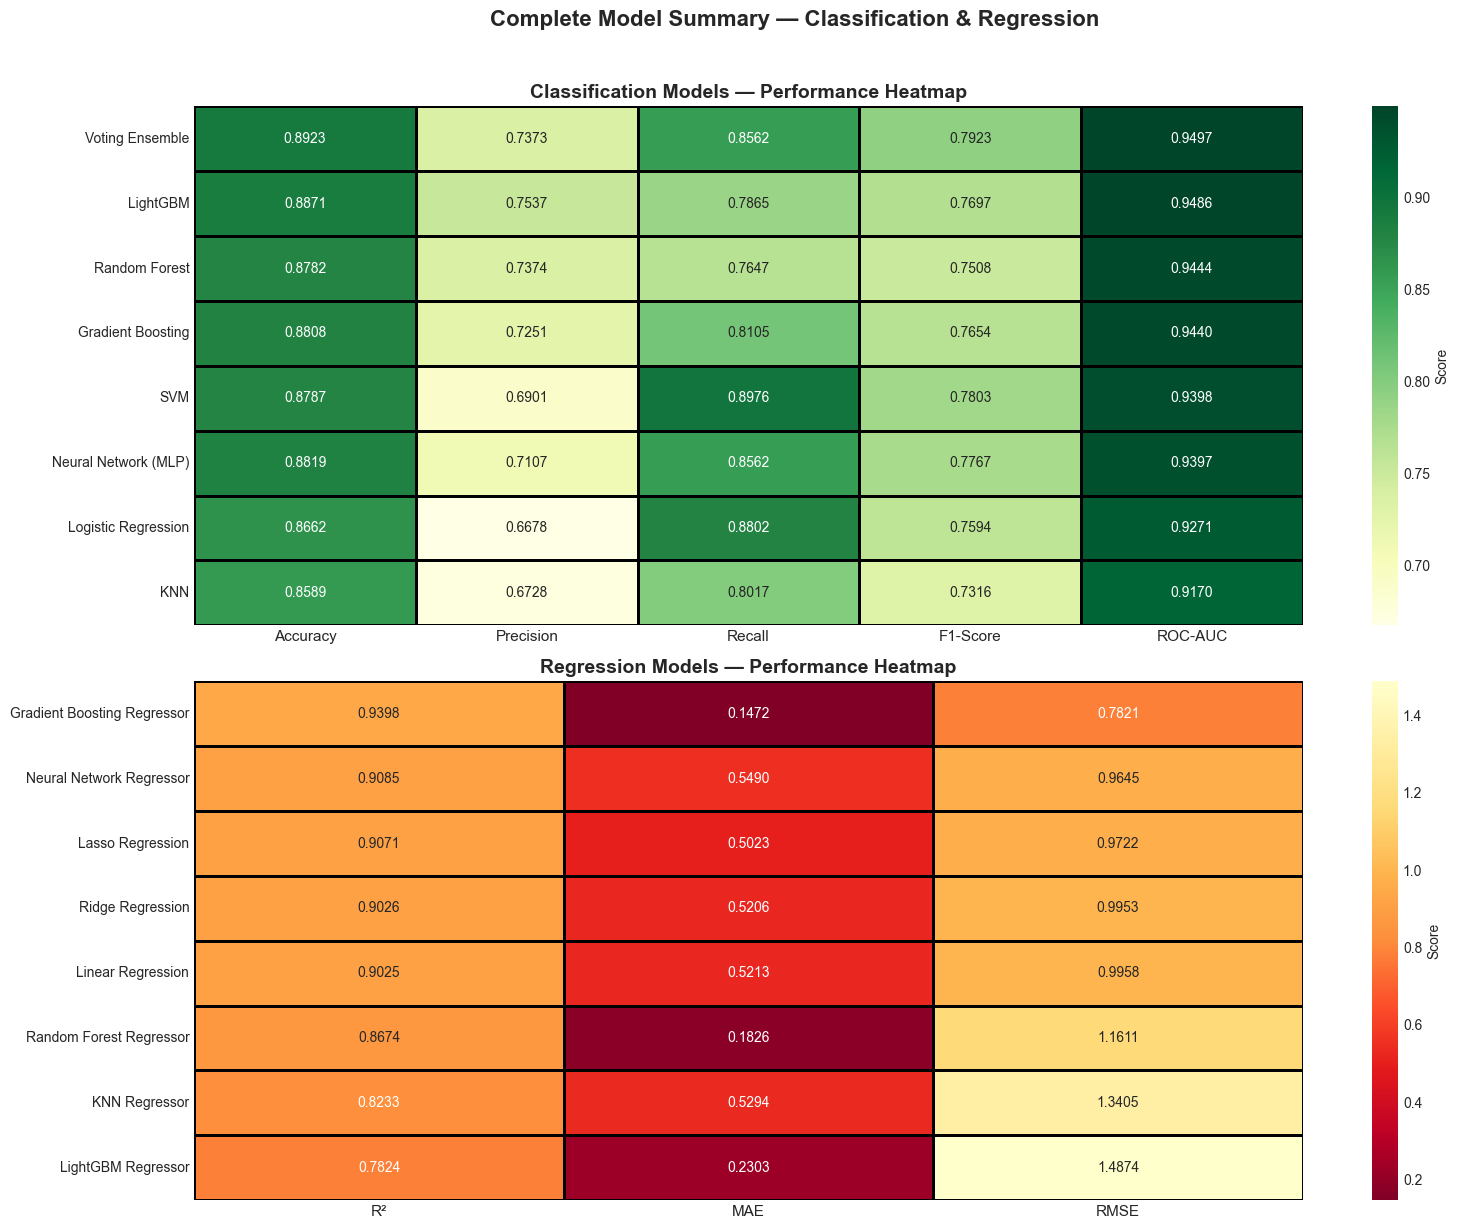

✓ Saved: 15_complete_model_summary.png

✓ Regression analysis complete! (8 models trained & evaluated)


In [40]:
    fig, axes = plt.subplots(2, 1, figsize=(16, 12))
    
    # Classification heatmap
    clf_heatmap_data = summary_df[['accuracy', 'precision', 'recall', 'f1', 'roc_auc']]
    sns.heatmap(clf_heatmap_data, annot=True, fmt='.4f', cmap='YlGn',
                ax=axes[0], linewidths=1, linecolor='black', cbar_kws={'label': 'Score'})
    axes[0].set_title('Classification Models — Performance Heatmap', fontsize=14, fontweight='bold')
    axes[0].set_ylabel('')
    axes[0].set_xticklabels(['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC'], fontsize=11)
    
    # Regression heatmap
    reg_heatmap_data = reg_summary_df[['r2', 'mae', 'rmse']]
    sns.heatmap(reg_heatmap_data, annot=True, fmt='.4f', cmap='YlOrRd_r',
                ax=axes[1], linewidths=1, linecolor='black', cbar_kws={'label': 'Score'})
    axes[1].set_title('Regression Models — Performance Heatmap', fontsize=14, fontweight='bold')
    axes[1].set_ylabel('')
    axes[1].set_xticklabels(['R²', 'MAE', 'RMSE'], fontsize=11)
    
    plt.suptitle('Complete Model Summary — Classification & Regression',
                 fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('visualizations/15_complete_model_summary.png', dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()
    print("✓ Saved: 15_complete_model_summary.png")
    
    print("\n✓ Regression analysis complete! (8 models trained & evaluated)")


## Section 6: Key Insights & Findings

In [41]:
print("STATISTICAL INSIGHTS:")
print("-" * 80)

if 'koi_disposition' in df_clean.columns:
    confirmed = df_clean[df_clean['koi_disposition'] == 'CONFIRMED']
    false_positive = df_clean[df_clean['koi_disposition'] == 'FALSE POSITIVE']
    
    print(f"\n1. EXOPLANET CONFIRMATION:")
    print(f"   - Total candidates analyzed: {len(df_clean):,}")
    print(f"   - Confirmed exoplanets: {len(confirmed):,} ({len(confirmed)/len(df_clean)*100:.2f}%)")
    print(f"   - False positives: {len(false_positive):,} ({len(false_positive)/len(df_clean)*100:.2f}%)")
    
    if 'koi_prad' in df_clean.columns:
        print(f"\n2. PLANETARY CHARACTERISTICS:")
        print(f"   - Average planetary radius (confirmed): {confirmed['koi_prad'].mean():.2f} Earth radii")
        print(f"   - Median planetary radius (confirmed): {confirmed['koi_prad'].median():.2f} Earth radii")
        print(f"   - Smallest detected planet: {confirmed['koi_prad'].min():.2f} Earth radii")
        print(f"   - Largest detected planet: {confirmed['koi_prad'].max():.2f} Earth radii")
    
    if 'koi_period' in df_clean.columns:
        print(f"\n3. ORBITAL CHARACTERISTICS:")
        print(f"   - Average orbital period (confirmed): {confirmed['koi_period'].mean():.2f} days")
        print(f"   - Shortest orbital period: {confirmed['koi_period'].min():.2f} days")
        print(f"   - Longest orbital period: {confirmed['koi_period'].max():.2f} days")
    
    if 'koi_teq' in df_clean.columns:
        print(f"\n4. HABITABILITY POTENTIAL:")
        habitable_temp = confirmed[(confirmed['koi_teq'] >= 200) & (confirmed['koi_teq'] <= 350)]
        print(f"   - Exoplanets in habitable temperature range (200-350K): {len(habitable_temp)}")
        print(f"   - Percentage of confirmed planets: {len(habitable_temp)/len(confirmed)*100:.2f}%")

print(f"\n5. CLASSIFICATION INSIGHTS (8 Models):")
print(f"   - Best classifier: {best_clf_name}")
print(f"   - Best ROC-AUC: {summary_df.loc[best_clf_name, 'roc_auc']:.4f}")
print(f"   - All models achieve strong predictive power for exoplanet confirmation")
print(f"   - Top predictive features: transit characteristics and stellar properties")

print(f"\n6. REGRESSION INSIGHTS (8 Models):")
print(f"   - Best regressor: {best_reg_name}")
print(f"   - Best R²: {reg_summary_df.loc[best_reg_name, 'r2']:.4f}")
print(f"   - Best MAE: {reg_summary_df.loc[best_reg_name, 'mae']:.4f} Earth radii")
print(f"   - Ensemble & tree-based methods significantly outperform linear baselines")

print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)
print(f"\n✓ All visualizations saved in 'visualizations/' directory")
print(f"✓ Total visualizations generated: 15")
print(f"  - EDA visualizations: 7 (Figures 01–07)")
print(f"  - Classification visualizations: 4 (Figures 08–11)")
print(f"  - Regression visualizations: 4 (Figures 12–15)")
print(f"\n✓ Classification models trained: 8")
print(f"  Logistic Regression, Random Forest, Gradient Boosting, KNN,")
print(f"  Neural Network (MLP), SVM, LightGBM, Voting Ensemble")
print(f"\n✓ Regression models trained: 8")
print(f"  Linear, Ridge, Lasso, KNN, Random Forest, Gradient Boosting,")
print(f"  LightGBM, Neural Network (MLP)")
print(f"\nNext Steps:")
print("  1. Review visualizations in the 'visualizations' folder")
print("  2. Open kepler_analysis.ipynb for interactive analysis")
print("  3. Export notebook to PDF for submission")
print("\n" + "="*80)


STATISTICAL INSIGHTS:
--------------------------------------------------------------------------------

1. EXOPLANET CONFIRMATION:
   - Total candidates analyzed: 9,564
   - Confirmed exoplanets: 2,293 (23.98%)
   - False positives: 5,023 (52.52%)

2. PLANETARY CHARACTERISTICS:
   - Average planetary radius (confirmed): 2.85 Earth radii
   - Median planetary radius (confirmed): 2.17 Earth radii
   - Smallest detected planet: 0.27 Earth radii
   - Largest detected planet: 48.16 Earth radii

3. ORBITAL CHARACTERISTICS:
   - Average orbital period (confirmed): 23.89 days
   - Shortest orbital period: 0.34 days
   - Longest orbital period: 154.66 days

4. HABITABILITY POTENTIAL:
   - Exoplanets in habitable temperature range (200-350K): 118
   - Percentage of confirmed planets: 5.15%

5. CLASSIFICATION INSIGHTS (8 Models):
   - Best classifier: Voting Ensemble
   - Best ROC-AUC: 0.9497
   - All models achieve strong predictive power for exoplanet confirmation
   - Top predictive features: 